In [ ]:
import math, time, contextlib
from functools import partial
import torch, torch.nn as nn, torch.nn.functional as F
from torch.nn.init import trunc_normal_
from torch.nn.attention import SDPBackend, sdpa_kernel

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
AMP = device == "cuda"
AMP_DTYPE = torch.float16

print("torch      :", torch.__version__)
print("device     :", device)
if device == "cuda":
    print("GPU        :", torch.cuda.get_device_name(0))
    cap = torch.cuda.get_device_capability(0)
    print("compute cap:", cap)
torch.backends.cudnn.benchmark = True

FLASH_BACKENDS = [SDPBackend.FLASH_ATTENTION, SDPBackend.EFFICIENT_ATTENTION, SDPBackend.MATH]

torch      : 2.3.1
device     : cpu


In [2]:
def to_2tuple(x):
    return x if isinstance(x, tuple) else (x, x)

def drop_path(x, p=0., training=False):
    if p == 0. or not training: return x
    keep = 1 - p
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    rt = keep + torch.rand(shape, dtype=x.dtype, device=x.device)
    return x.div(keep) * rt.floor_()

class DropPath(nn.Module):
    def __init__(self, p=None): super().__init__(); self.p = p
    def forward(self, x): return drop_path(x, self.p, self.training)

class Mlp(nn.Module):
    def __init__(self, inf, hid=None, out=None, drop=0.):
        super().__init__(); out = out or inf; hid = hid or inf
        self.fc1 = nn.Linear(inf, hid); self.act = nn.GELU(); self.fc2 = nn.Linear(hid, out); self.drop = nn.Dropout(drop)
    def forward(self, x): return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))

class IWSA(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0., ws=7, attn_impl='manual'):
        super().__init__(); assert ws != 1 and dim % num_heads == 0
        self.dim=dim; self.num_heads=num_heads; hd=dim//num_heads; self.scale=hd**-0.5
        self.qkv=nn.Linear(dim, dim*3, bias=qkv_bias); self.attn_drop=nn.Dropout(attn_drop)
        self.proj=nn.Linear(dim, dim); self.proj_drop=nn.Dropout(proj_drop); self.ws=ws
        self.lim_func=nn.Conv2d(dim, dim, 3, 1, 1, groups=dim); self.attn_impl=attn_impl
    def img2win(self, x, H, W):
        B,N,C=x.shape; hg,wg=H//self.ws,W//self.ws
        x=x.reshape(B,hg,self.ws,wg,self.ws,C).transpose(2,3)
        return x.reshape(B,hg*wg,-1,self.num_heads,C//self.num_heads).permute(0,1,3,2,4)
    def win2img(self, x, H, W):
        hg,wg=H//self.ws,W//self.ws; B=x.shape[0]; C=x.shape[-1]*self.num_heads
        x=x.permute(0,1,3,2,4).reshape(B,hg,wg,self.ws,self.ws,C)
        return x.transpose(2,3).reshape(B,H,W,C).permute(0,3,1,2).contiguous()
    def forward(self, x, H, W):
        B,N,C=x.shape; hg,wg=H//self.ws,W//self.ws
        qkv=self.qkv(x).reshape(B,N,3,C).permute(2,0,1,3); q,k,v=qkv[0],qkv[1],qkv[2]
        q=self.img2win(q,H,W); k=self.img2win(k,H,W); v=self.img2win(v,H,W)
        v_inter=self.lim_func(self.win2img(v,H,W)).flatten(2).transpose(1,2).contiguous()
        if self.attn_impl=='sdpa':
            o=F.scaled_dot_product_attention(q,k,v,scale=self.scale,dropout_p=self.attn_drop.p if self.training else 0.)
        else:
            a=(q@k.transpose(-2,-1))*self.scale; a=self.attn_drop(a.softmax(-1)); o=a@v
        o=o.transpose(2,3).reshape(B,hg,wg,self.ws,self.ws,C)
        x=o.transpose(2,3).reshape(B,N,C)+v_inter
        return self.proj_drop(self.proj(x))

class SSA(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0., sr_ratio=1., c_ratio=1.25, attn_impl='manual'):
        super().__init__(); assert dim % num_heads == 0
        self.num_heads=num_heads; hd=dim//num_heads; self.sr_ratio=sr_ratio; self.c_new=int(dim*c_ratio)
        self.scale=(hd*c_ratio)**-0.5; self.attn_impl=attn_impl
        if sr_ratio>1:
            self.q=nn.Linear(dim,self.c_new,bias=qkv_bias)
            self.reduction=nn.Sequential(nn.Conv2d(dim,dim,sr_ratio,sr_ratio,groups=dim), nn.Conv2d(dim,self.c_new,1,1))
            self.norm_act=nn.Sequential(nn.LayerNorm(self.c_new), nn.GELU())
            self.k=nn.Linear(self.c_new,self.c_new,bias=qkv_bias); self.v=nn.Linear(self.c_new,dim,bias=qkv_bias)
        else:
            self.q=nn.Linear(dim,dim,bias=qkv_bias); self.kv=nn.Linear(dim,dim*2,bias=qkv_bias)
        self.proj=nn.Linear(dim,dim); self.attn_drop=nn.Dropout(attn_drop); self.proj_drop=nn.Dropout(proj_drop)
    def forward(self, x, H, W):
        B,N,C=x.shape
        if self.sr_ratio>1:
            _x=x.permute(0,2,1).reshape(B,C,H,W); _x=self.reduction(_x).reshape(B,self.c_new,-1).permute(0,2,1); _x=self.norm_act(_x)
            q=self.q(x).reshape(B,N,self.num_heads,self.c_new//self.num_heads).permute(0,2,1,3)
            k=self.k(_x).reshape(B,-1,self.num_heads,self.c_new//self.num_heads).permute(0,2,1,3)
            v=self.v(_x).reshape(B,-1,self.num_heads,C//self.num_heads).permute(0,2,1,3)
        else:
            q=self.q(x).reshape(B,N,self.num_heads,C//self.num_heads).permute(0,2,1,3)
            kv=self.kv(x).reshape(B,-1,2,self.num_heads,C//self.num_heads).permute(2,0,3,1,4); k,v=kv[0],kv[1]
        if self.attn_impl=='sdpa':
            o=F.scaled_dot_product_attention(q,k,v,scale=self.scale,dropout_p=self.attn_drop.p if self.training else 0.)
        else:
            a=(q@k.transpose(-2,-1))*self.scale; a=self.attn_drop(a.softmax(-1)); o=a@v
        x=o.transpose(1,2).reshape(B,N,C)
        return self.proj_drop(self.proj(x))

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0., drop_path=0.,
                 norm_layer=nn.LayerNorm, c_ratio=1.25, sr_ratio=1, ws=1, attn_impl='manual'):
        super().__init__(); self.norm1=norm_layer(dim)
        if ws==1:
            self.attn=SSA(dim,num_heads,qkv_bias,attn_drop,drop,sr_ratio,c_ratio,attn_impl)
        else:
            self.attn=IWSA(dim,num_heads,qkv_bias,attn_drop,drop,ws,attn_impl)
        self.drop_path=DropPath(drop_path) if drop_path>0 else nn.Identity()
        self.norm2=norm_layer(dim); self.mlp=Mlp(dim, int(dim*mlp_ratio), drop=drop)
    def forward(self, x, H, W):
        x=x+self.drop_path(self.attn(self.norm1(x),H,W)); x=x+self.drop_path(self.mlp(self.norm2(x))); return x

class ConvPatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=64, overlapping=3, norm_layer=nn.LayerNorm):
        super().__init__(); img_size=to_2tuple(img_size); patch_size=to_2tuple(patch_size); self.patch_size=patch_size
        ks=to_2tuple(patch_size[0]+overlapping); pad=to_2tuple(overlapping)
        self.proj=nn.Conv2d(in_chans, embed_dim, ks, patch_size, pad); self.norm=norm_layer(embed_dim)
    def forward(self, x):
        B,C,H,W=x.shape; x=self.proj(x).flatten(2).transpose(1,2); x=self.norm(x)
        return x, (H//self.patch_size[0], W//self.patch_size[1])

class PosCNN(nn.Module):
    def __init__(self, in_chans, embed_dim, s=1):
        super().__init__(); self.proj=nn.Sequential(nn.Conv2d(in_chans, embed_dim, 3, s, 1, bias=True, groups=embed_dim)); self.s=s
    def forward(self, x, H, W):
        B,N,C=x.shape; f=x.transpose(1,2).contiguous().view(B,C,H,W)
        x=self.proj(f)+f if self.s==1 else self.proj(f)
        return x.flatten(2).transpose(1,2)

class TinyScalableViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=1, num_classes=10,
                 embed_dims=[32,64], num_heads=[2,4], mlp_ratios=[2,2], qkv_bias=True,
                 drop_rate=0., attn_drop_rate=0., drop_path_rate=0.1,
                 norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[2,2], sr_ratios=[2,1],
                 wss=[4,4], c_ratios=[1.25,1], attn_impl='manual'):
        super().__init__(); self.depths=depths; self.embed_dims=embed_dims
        dpr=[x.item() for x in torch.linspace(0,drop_path_rate,sum(depths))]; cur=0
        self.patch_embeds=nn.ModuleList(); self.pos_block=nn.ModuleList(); self.pos_drops=nn.ModuleList(); self.stages=nn.ModuleList()
        for k in range(len(depths)):
            if k==0:
                self.patch_embeds.append(ConvPatchEmbed(img_size,patch_size,in_chans,embed_dims[k],3,norm_layer))
            else:
                self.patch_embeds.append(ConvPatchEmbed(img_size//patch_size//2**(k-1),2,embed_dims[k-1],embed_dims[k],1,norm_layer))
            self.pos_block.append(PosCNN(embed_dims[k],embed_dims[k])); self.pos_drops.append(nn.Dropout(drop_rate))
            blocks=nn.ModuleList([Block(embed_dims[k],num_heads[k],mlp_ratios[k],qkv_bias,drop_rate,attn_drop_rate,
                    dpr[cur+i],norm_layer,c_ratios[k],sr_ratios[k],1 if i%2==1 else wss[k],attn_impl) for i in range(depths[k])])
            self.stages.append(blocks); cur+=depths[k]
        self.norm=norm_layer(embed_dims[-1]); self.head=nn.Linear(embed_dims[-1],num_classes)
        self.apply(self._init)
    def _init(self,m):
        if isinstance(m,nn.Linear):
            trunc_normal_(m.weight,std=.02)
            if m.bias is not None: nn.init.constant_(m.bias,0)
        elif isinstance(m,nn.LayerNorm): nn.init.constant_(m.bias,0); nn.init.constant_(m.weight,1.)
        elif isinstance(m,nn.Conv2d):
            fo=m.kernel_size[0]*m.kernel_size[1]*m.out_channels//m.groups; m.weight.data.normal_(0,math.sqrt(2./fo))
            if m.bias is not None: m.bias.data.zero_()
    def forward(self,x):
        B=x.shape[0]
        for i in range(len(self.depths)):
            x,(H,W)=self.patch_embeds[i](x); x=self.pos_drops[i](x)
            for j,blk in enumerate(self.stages[i]):
                x=blk(x,H,W)
                if j==0: x=self.pos_block[i](x,H,W)
            if i<len(self.depths)-1: x=x.reshape(B,H,W,-1).permute(0,3,1,2).contiguous()
        x=self.norm(x).mean(1); return self.head(x)

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tf)

BATCH = 256
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=AMP, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=512,   shuffle=False, num_workers=2, pin_memory=AMP)
print(len(train_ds), "train /", len(test_ds), "test")

60000 train / 10000 test


In [6]:
def evaluate(model):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, y in test_dl:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device, dtype=AMP_DTYPE, enabled=AMP):
                pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += y.numel()
    return 100.0 * correct / total

def run(attn_impl, backends, epochs=3, seed=0, tag=""):
    torch.manual_seed(seed)
    model = TinyScalableViT(attn_impl=attn_impl).to(device)
    init_state = {k: v.clone() for k, v in model.state_dict().items()}
    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)
    ctx = sdpa_kernel(backends) if backends is not None else contextlib.nullcontext()

    hist = {"epoch_time": [], "loss": [], "acc": []}
    with ctx:
        for i, (x, y) in enumerate(train_dl):
            if i >= 3: break
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device, dtype=AMP_DTYPE, enabled=AMP):
                loss = F.cross_entropy(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

        model.load_state_dict(init_state)
        opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler = torch.cuda.amp.GradScaler(enabled=AMP)

        for ep in range(epochs):
            model.train(); running = 0.0
            if device == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            for x, y in train_dl:
                x, y = x.to(device), y.to(device)
                opt.zero_grad(set_to_none=True)
                with torch.autocast(device, dtype=AMP_DTYPE, enabled=AMP):
                    loss = F.cross_entropy(model(x), y)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
                running += loss.item()
            if device == "cuda": torch.cuda.synchronize()
            dt = time.perf_counter() - t0
            acc = evaluate(model)
            hist["epoch_time"].append(dt); hist["loss"].append(running/len(train_dl)); hist["acc"].append(acc)
            print(f"[{tag}] epoch {ep+1}/{epochs}  {dt:6.2f}s  loss {running/len(train_dl):.4f}  test_acc {acc:.2f}%")
    return hist

In [ ]:
EPOCHS = 3
print(">>> Variante SANS flash (attention manuelle)")
h_manual = run("manual", backends=None,           epochs=EPOCHS, seed=0, tag="no-flash")
print("\n>>> Variante AVEC flash (SDPA, flash la ou possible)")
h_flash  = run("sdpa",   backends=FLASH_BACKENDS, epochs=EPOCHS, seed=0, tag="flash   ")

Temps median / epoch  |  sans flash: 19.48s   avec flash: 20.13s   => speedup x0.97
Accuracy finale       |  sans flash: 96.01%   avec flash: 96.01%


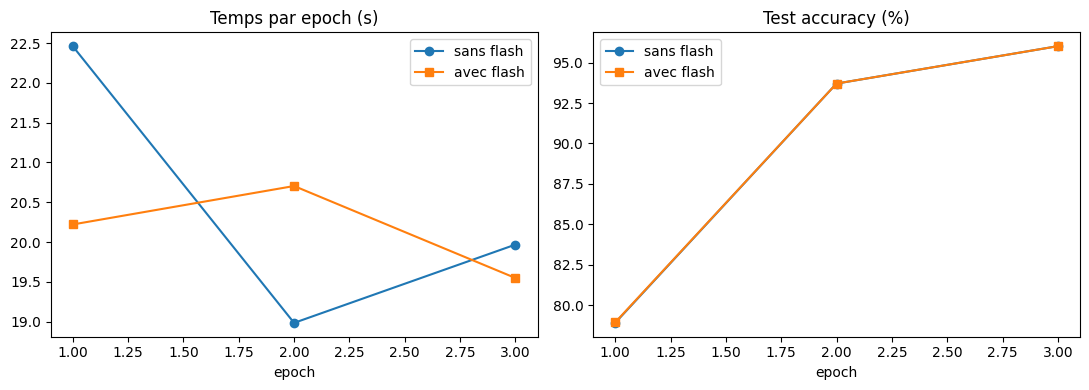

In [ ]:
import statistics as st
def med(xs): return st.median(xs[1:]) if len(xs) > 1 else xs[0]

t_no, t_fl = med(h_manual["epoch_time"]), med(h_flash["epoch_time"])
print(f"Average time / epoch  |  without flash: {t_no:.2f}s with flash: {t_fl:.2f}s   "
      f"=> speedup x{t_no/t_fl:.2f}")
print(f"Accuracy     |  without flash: {h_manual['acc'][-1]:.2f}%   with flash: {h_flash['acc'][-1]:.2f}%")

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ep = range(1, EPOCHS+1)
    ax[0].plot(ep, h_manual["epoch_time"], "o-", label="without flash")
    ax[0].plot(ep, h_flash["epoch_time"],  "s-", label="with flash")
    ax[0].set_title("Time per epoch (s)"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(ep, h_manual["acc"], "o-", label="without flash")
    ax[1].plot(ep, h_flash["acc"],  "s-", label="with flash")
    ax[1].set_title("Test accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()
except Exception as e:
    print("plot skipped:", e)

In [ ]:
def try_flash(name, q, k, v):
    q, k, v = q.to(device), k.to(device), v.to(device)
    if AMP: q, k, v = q.half(), k.half(), v.half()
    try:
        with sdpa_kernel([SDPBackend.FLASH_ATTENTION]):
            F.scaled_dot_product_attention(q, k, v)
        print(f"  {name:38s} -> FLASH OK")
    except Exception as e:
        print(f"  {name:38s} -> refuse ({str(e).splitlines()[0][:60]})")

print("device:", device, "(flash only CUDA Ampere+)")
try_flash("IWSA (q/k/v hd=16, equal)",        torch.randn(8,2,16,16), torch.randn(8,2,16,16), torch.randn(8,2,16,16))
try_flash("SSA  c_ratio=1  (hd=16, equal)",   torch.randn(8,4,16,16), torch.randn(8,4,16,16), torch.randn(8,4,16,16))
try_flash("SSA  c_ratio=1.25 (q/k=20, v=16)", torch.randn(8,2,64,20), torch.randn(8,2,16,20), torch.randn(8,2,16,16))